# Predicción de Termoestabilidad — Pipeline v4 (Dipéptidos)

### RAM necesaria: ~856 MB para el dataset completo 

### ¿Por qué los dipéptidos ayudan?
Los monopéptidos (% de cada AA) no capturan el **orden** de la secuencia.
Los dipéptidos (frecuencia de cada par consecutivo, ej: Lys→Arg) reflejan
patrones de estructura secundaria que correlacionan con termoestabilidad.
La literatura reporta mejoras de R² de 8-15 puntos al añadirlos.

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'lightgbm', '--quiet'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ─── AJUSTA ESTAS RUTAS ───────────────────────────────────────────────────
RUTA_X_TRAIN = '/TU/RUTA/DATASET/X_train.npy'
RUTA_Y_TRAIN = '/TU/RUTA/DATASET/y_train.npy'
RUTA_X_TEST  = '/TU/RUTA/DATASET/X_test.npy'
RUTA_Y_TEST  = '/TU/RUTA/DATASET/y_test.npy'
# ─────────────────────────────────────────────────────────────────────────

print(f'LightGBM: {lgb.__version__}')
print('✅ Listo')

LightGBM: 4.6.0
✅ Listo


## PASO 1: Muestreo 

In [ ]:
y_full = np.load(RUTA_Y_TRAIN)
print(f'Total proteínas: {len(y_full):,}  |  Rango: {y_full.min():.0f}-{y_full.max():.0f}°C')

N = 500_000
np.random.seed(42)
idx = np.random.choice(len(y_full), size=N, replace=False)
#  NO ordenar idx — mantiene alineamiento X↔y

y_sample = y_full[idx].copy()
print(f'Muestra: {N:,} proteínas')
print(f'  Psicrófilos (<20°C):  {np.mean(y_sample<20)*100:.1f}%')
print(f'  Mesófilos (20-45°C):  {np.mean((y_sample>=20)&(y_sample<=45))*100:.1f}%')
print(f'  Termófilos (>45°C):   {np.mean(y_sample>45)*100:.1f}%')

Total proteínas: 6,149,359  |  Rango: 4-103°C
Muestra: 500,000 proteínas
  Psicrófilos (<20°C):  2.5%
  Mesófilos (20-45°C):  83.5%
  Termófilos (>45°C):   14.0%


## PASO 2: Extracción de features — 28 monopéptidos + 400 dipéptidos = 428 features

Un **dipéptido** es un par de aminoácidos consecutivos en la secuencia.
Con 20 AA posibles hay 20×20=400 combinaciones.
La frecuencia de cada dipéptido captura patrones locales de estructura
que los monopéptidos no pueden ver.

In [ ]:
# Índices de hidrofobicidad Kyte-Doolittle
KD = np.array([
     1.8,  2.5, -3.5, -3.5,  2.8, -0.4, -3.2,  4.5, -3.9,  3.8,
     1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7,  4.2, -0.9, -1.3
], dtype=np.float32)

AA_LETRAS = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y']

# Nombres de todas las features
NOMBRES_MONO = (
    [f'pct_{aa}' for aa in AA_LETRAS] +
    ['log_longitud','GRAVY','aromaticidad','pct_Cys','carga_pos','carga_neg','balance_cargas','pct_Pro']
)  # 28 features

NOMBRES_DI = [f'di_{a}{b}' for a in AA_LETRAS for b in AA_LETRAS]  # 400 features

NOMBRES_FEATURES = NOMBRES_MONO + NOMBRES_DI  # 428 total
N_FEATURES = len(NOMBRES_FEATURES)

print(f'Total features: {N_FEATURES}')
print(f'  Monopéptidos y bioquímicas: {len(NOMBRES_MONO)}')
print(f'  Dipéptidos: {len(NOMBRES_DI)}')
print(f'  RAM estimada (500k×{N_FEATURES}×4 bytes): {500_000*N_FEATURES*4/1e6:.0f} MB')

Total features: 428
  Monopéptidos y bioquímicas: 28
  Dipéptidos: 400
  RAM estimada (500k×428×4 bytes): 856 MB


In [ ]:
def extraer_features_v4(X_seqs):
    """
    Extrae 428 features (28 monopéptidos/bioquímicas + 400 dipéptidos).
    X_seqs: array (N, 650) de enteros 0-20
    Retorna: array (N, 428) float32
    """
    N = X_seqs.shape[0]
    F = np.zeros((N, N_FEATURES), dtype=np.float32)

    for i in range(N):
        aa = X_seqs[i]
        aa = aa[aa > 0].astype(np.int64)      # Quitar padding
        L = len(aa)
        if L == 0:
            continue

        # ── Monopéptidos (features 0-19) ─────────────────────────────────
        c = np.bincount(aa, minlength=21)[1:21].astype(np.float32)
        F[i, :20]  = c / L * 100

        # ── Features bioquímicas (features 20-27) ─────────────────────────
        F[i, 20]   = np.log1p(L)
        F[i, 21]   = np.dot(c, KD) / L
        F[i, 22]   = (c[4]+c[19]+c[18]) / L * 100   # aromaticidad F+Y+W
        F[i, 23]   = c[1] / L * 100                  # % Cys
        F[i, 24]   = (c[8]+c[14]) / L * 100          # carga+ K+R
        F[i, 25]   = (c[2]+c[3]) / L * 100           # carga- D+E
        F[i, 26]   = F[i, 24] - F[i, 25]             # balance
        F[i, 27]   = c[12] / L * 100                 # % Pro

        # ── Dipéptidos (features 28-427) ──────────────────────────────────
        # Par (a,b): índice = (a-1)*20 + (b-1), donde a,b ∈ [1,20]
        # Filtramos pares que involucren ceros embebidos (padding interno)
        if L >= 2:
            a_left  = aa[:-1]
            a_right = aa[1:]
            validos = (a_left >= 1) & (a_left <= 20) & (a_right >= 1) & (a_right <= 20)
            a_left, a_right = a_left[validos], a_right[validos]
            n_pares = len(a_left)
            if n_pares > 0:
                pares = (a_left - 1) * 20 + (a_right - 1)  # índices 0-399
                conteos_di = np.bincount(pares, minlength=400).astype(np.float32)
                F[i, 28:428] = conteos_di / n_pares * 100

    return F

# Test rápido de la función
test_seq = np.array([[1,2,3,4,5,6,0,0,0,0]], dtype=np.int64)
test_feat = extraer_features_v4(test_seq)
assert test_feat.shape == (1, 428), f'Error: shape {test_feat.shape}'
assert test_feat[0, 28:432].sum() > 0, 'Error: dipéptidos todos cero'
print(f'✅ Función verificada: output shape {test_feat.shape}')
print(f'   Dipéptidos no-cero en secuencia de prueba: {(test_feat[0,28:]>0).sum()}')

✅ Función verificada: output shape (1, 428)
   Dipéptidos no-cero en secuencia de prueba: 5


In [ ]:
# Extracción por lotes
print('Cargando secuencias y extrayendo features (monopéptidos + dipéptidos)...')
print('(Tardará ~5-8 minutos para 500k proteínas)')
X_mmap = np.load(RUTA_X_TRAIN, mmap_mode='r')

LOTE = 50_000
n_lotes = int(np.ceil(N / LOTE))
bloques = []

for k in range(n_lotes):
    i0, i1 = k * LOTE, min((k+1) * LOTE, N)
    idx_lote = idx[i0:i1]            # Mismos índices sin reordenar
    X_lote = np.array(X_mmap[idx_lote])
    bloques.append(extraer_features_v4(X_lote))
    del X_lote
    if (k+1) % 2 == 0 or k == n_lotes-1:
        print(f'  Lote {k+1}/{n_lotes} — {i1:,}/{N:,} proteínas')
        gc.collect()

X = np.vstack(bloques)
del bloques
gc.collect()

print(f'\n✅ Extracción completa')
print(f'   X shape: {X.shape}  |  RAM: {X.nbytes/1e6:.0f} MB')
print(f'   y_sample shape: {y_sample.shape}')

# Verificación de alineamiento
idx_frio  = np.where(y_sample < 15)[0][:5]
idx_calor = np.where(y_sample > 80)[0][:5]
gravy_frio  = X[idx_frio,  21].mean()
gravy_calor = X[idx_calor, 21].mean()
print(f'\n🔍 Verificación alineamiento X↔y:')
print(f'   GRAVY frías (<15°C):    {gravy_frio:.3f}')
print(f'   GRAVY calientes (>80°C):{gravy_calor:.3f}')
if abs(gravy_calor - gravy_frio) > 0.05:
    print('   ✅ Diferencia biológicamente plausible — alineamiento correcto')
else:
    print('   ⚠️  ADVERTENCIA: valores muy similares — posible desalineamiento')

Cargando secuencias y extrayendo features (monopéptidos + dipéptidos)...
(Tardará ~5-8 minutos para 500k proteínas)
  Lote 2/10 — 100,000/500,000 proteínas
  Lote 4/10 — 200,000/500,000 proteínas
  Lote 6/10 — 300,000/500,000 proteínas
  Lote 8/10 — 400,000/500,000 proteínas
  Lote 10/10 — 500,000/500,000 proteínas

✅ Extracción completa
   X shape: (500000, 428)  |  RAM: 856 MB
   y_sample shape: (500000,)

🔍 Verificación alineamiento X↔y:
   GRAVY frías (<15°C):    -0.385
   GRAVY calientes (>80°C):0.445
   ✅ Diferencia biológicamente plausible — alineamiento correcto


## PASO 3: Split, pesos y entrenamiento

In [ ]:
bins = np.digitize(y_sample, bins=[20, 45, 65, 80])
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_sample, test_size=0.2, random_state=42, stratify=bins
)

# Pesos simples de 3 niveles 
w = np.ones(len(y_tr), dtype=np.float32)
w[y_tr > 65] = 6.0
w[(y_tr > 45) & (y_tr <= 65)] = 3.0

print(f'Train: {X_tr.shape}  |  Val: {X_val.shape}')
print(f'Pesos — 1x: {(w==1).sum():,}  |  3x: {(w==3).sum():,}  |  6x: {(w==6).sum():,}')

Train: (400000, 428)  |  Val: (100000, 428)
Pesos — 1x: 343,936  |  3x: 41,755  |  6x: 14,309


In [ ]:
params = {
    'objective':         'regression',
    'metric':            ['mae', 'rmse'],
    'num_leaves':        127,      # Más hojas: más capacidad para 428 features
    'learning_rate':     0.05,
    'min_child_samples': 30,
    'subsample':         0.8,
    'subsample_freq':    1,
    'colsample_bytree':  0.4,      # Reducido: con 428 features, 40% = ~171 por árbol
    'reg_alpha':         0.1,
    'reg_lambda':        0.5,
    'max_bin':           127,
    'num_threads':       8,
    'seed':              42,
    'verbose':           -1,
}

dtrain = lgb.Dataset(X_tr,  label=y_tr,  weight=w,
                     feature_name=NOMBRES_FEATURES, free_raw_data=False)
dval   = lgb.Dataset(X_val, label=y_val,
                     feature_name=NOMBRES_FEATURES, reference=dtrain, free_raw_data=False)

dtrain.construct()
print(f'Dataset: {dtrain.num_data():,} filas × {dtrain.num_feature()} features')
assert dtrain.num_data() == len(X_tr)
print('✅ Integridad verificada')

print('\n🚀 Entrenando...')
modelo = lgb.train(
    params, dtrain,
    num_boost_round=2000,
    valid_sets=[dval],
    valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=80, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)
print(f'\n✅ Listo — {modelo.num_trees()} árboles')
del dtrain, dval
gc.collect()

Dataset: 400,000 filas × 428 features
✅ Integridad verificada

🚀 Entrenando...


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


Training until validation scores don't improve for 80 rounds
[100]	val's l1: 9.17464	val's rmse: 11.7925
[200]	val's l1: 8.76867	val's rmse: 11.4443
[300]	val's l1: 8.56022	val's rmse: 11.2254
[400]	val's l1: 8.40301	val's rmse: 11.0549
[500]	val's l1: 8.28841	val's rmse: 10.9308
[600]	val's l1: 8.19197	val's rmse: 10.8305
[700]	val's l1: 8.10793	val's rmse: 10.742
[800]	val's l1: 8.03638	val's rmse: 10.6707
[900]	val's l1: 7.97023	val's rmse: 10.6021
[1000]	val's l1: 7.91232	val's rmse: 10.5441
[1100]	val's l1: 7.85976	val's rmse: 10.4928
[1200]	val's l1: 7.81048	val's rmse: 10.4438
[1300]	val's l1: 7.76449	val's rmse: 10.4006
[1400]	val's l1: 7.72549	val's rmse: 10.3627
[1500]	val's l1: 7.68661	val's rmse: 10.3253
[1600]	val's l1: 7.65076	val's rmse: 10.2915
[1700]	val's l1: 7.61687	val's rmse: 10.2614
[1800]	val's l1: 7.58419	val's rmse: 10.2326
[1900]	val's l1: 7.55376	val's rmse: 10.2057
[2000]	val's l1: 7.52642	val's rmse: 10.1818
Did not meet early stopping. Best iteration is:
[

346

📊 RESULTADOS EN VALIDACIÓN
   MAE:  7.53 °C   (v3: 8.22°C)
   RMSE: 10.18 °C  (v3: 10.98°C)
   R²:   0.3536       (v3: 0.2481)

📊 RENDIMIENTO POR SUBGRUPO:
  Grupo                              N     MAE       R²    Sesgo
  ---------------------------------------------------------------
  Psicrófilo (<20°C)             2,492   18.66  -29.149   +18.66
  Mesófilo (20-45°C)            83,471    6.13   -1.421    +3.64
  Termófilo mod (45-65°C)       10,420   12.03   -5.978   -10.77
  Termófilo ext (>65°C)          3,617   19.08   -5.981   -18.23


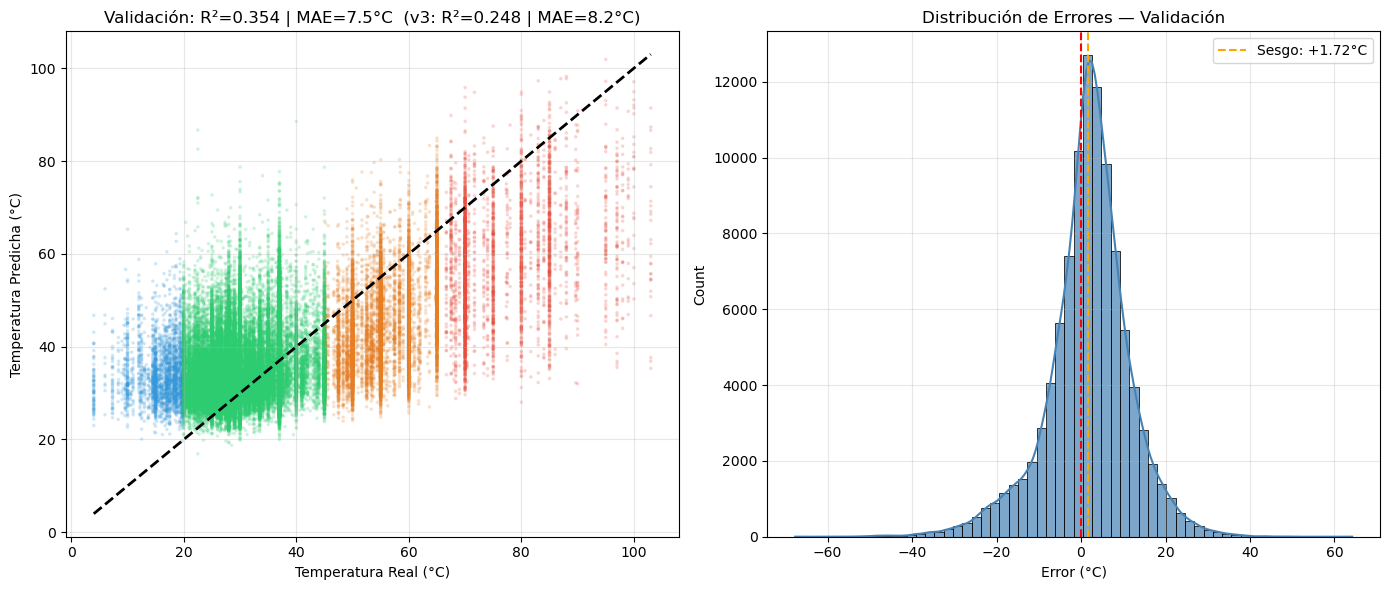

In [ ]:
# Evaluación en validación
pred_val = modelo.predict(X_val, num_iteration=modelo.best_iteration)

mae  = mean_absolute_error(y_val, pred_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
r2   = r2_score(y_val, pred_val)

print('=' * 55)
print('📊 RESULTADOS EN VALIDACIÓN')
print('=' * 55)
print(f'   MAE:  {mae:.2f} °C   ')
print(f'   RMSE: {rmse:.2f} °C  ')
print(f'   R²:   {r2:.4f}       ')
print('=' * 55)

# Por subgrupos
print('\n📊 RENDIMIENTO POR SUBGRUPO:')
grupos = {
    'Psicrófilo (<20°C)':       y_val < 20,
    'Mesófilo (20-45°C)':       (y_val >= 20) & (y_val <= 45),
    'Termófilo mod (45-65°C)':  (y_val > 45) & (y_val <= 65),
    'Termófilo ext (>65°C)':    y_val > 65,
}
print(f"  {'Grupo':<28} {'N':>7} {'MAE':>7} {'R²':>8} {'Sesgo':>8}")
print(f"  {'-'*63}")
for nombre, mask in grupos.items():
    if mask.sum() < 10: continue
    yr, yp = y_val[mask], pred_val[mask]
    r2_g = r2_score(yr, yp) if yr.std() > 0 else float('nan')
    sesgo = (yp - yr).mean()
    print(f"  {nombre:<28} {mask.sum():>7,} {mean_absolute_error(yr,yp):>7.2f} {r2_g:>8.3f} {sesgo:>+8.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores = np.select([y_val<20, y_val<=45, y_val<=65],
                    ['#3498db','#2ecc71','#e67e22'], default='#e74c3c')
axes[0].scatter(y_val, pred_val, c=colores, alpha=0.15, s=3)
lim = [y_val.min(), y_val.max()]
axes[0].plot(lim, lim, 'k--', lw=2)
axes[0].set_xlabel('Temperatura Real (°C)')
axes[0].set_ylabel('Temperatura Predicha (°C)')
axes[0].set_title(f'Validación: R²={r2:.3f} | MAE={mae:.1f}°C  ')
axes[0].grid(alpha=0.3)

errores = pred_val - y_val
sns.histplot(errores, bins=60, kde=True, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].axvline(errores.mean(), color='orange', lw=1.5, linestyle='--',
                label=f'Sesgo: {errores.mean():+.2f}°C')
axes[1].set_xlabel('Error (°C)')
axes[1].set_title('Distribución de Errores — Validación')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## PASO 4: Top dipéptidos más predictivos
Podemos ver qué pares de aminoácidos son los más informativos para la temperatura

📊 IMPORTANCIA POR TIPO DE FEATURE:
   Dipéptido: 400 features, ganancia total = 878855811 (55.6% del total)
   Mono/Bioquímica: 28 features, ganancia total = 702016445 (44.4% del total)

🔬 TOP 15 FEATURES MÁS PREDICTIVAS:
   🧪 pct_Q                ██████████████████████████████
   🧪 pct_E                █████████████████
   🧪 carga_pos            ███████████████
   🧪 pct_D                ██████████████
   🧪 pct_A                ███████████
   🧪 pct_T                ██████████
   🧪 pct_Y                ██████████
   🧪 pct_K                ███████
   🧪 pct_S                ███████
   🔗 di_EE                ███████
   🧪 pct_V                ██████
   🧪 balance_cargas       ██████
   🧪 pct_I                █████
   🧪 pct_N                █████
   🧪 GRAVY                ████


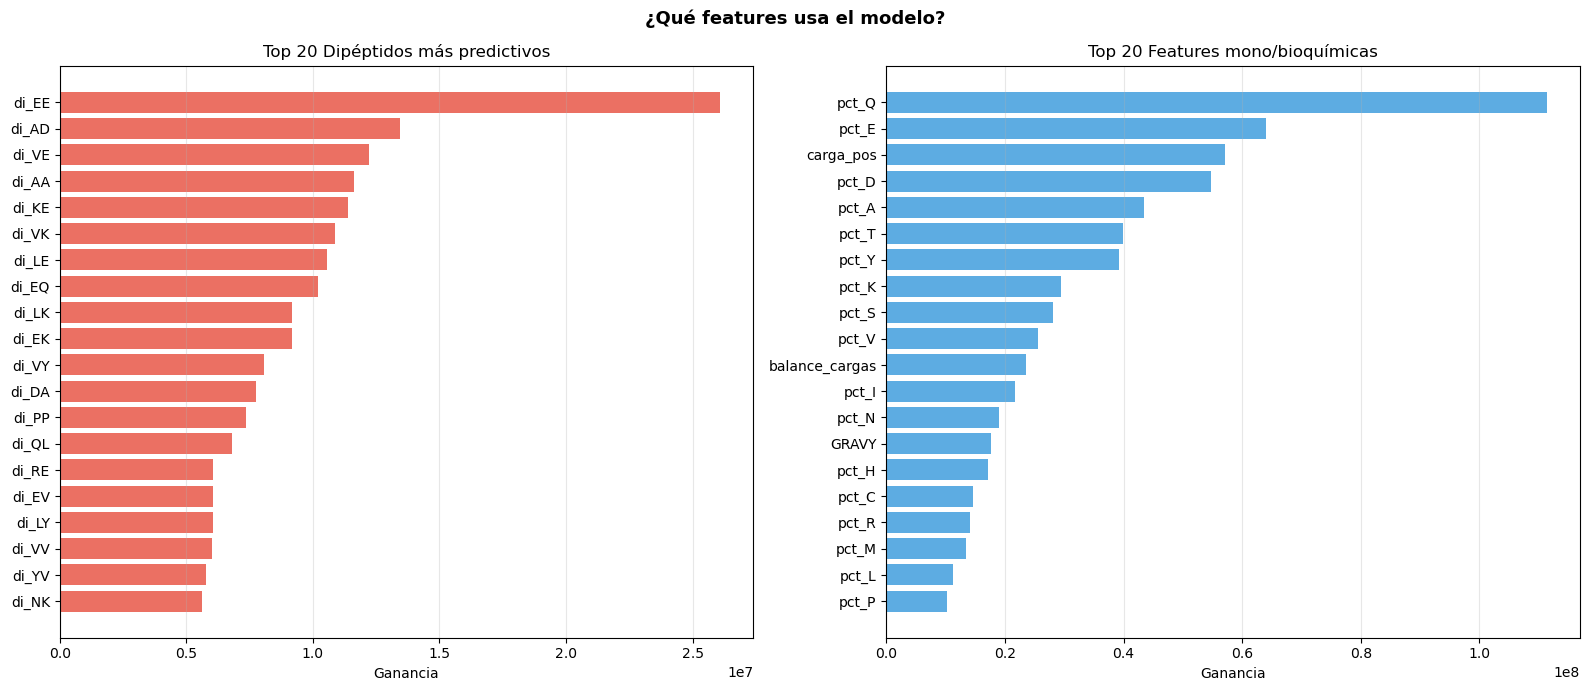

In [ ]:
imp = modelo.feature_importance(importance_type='gain')
df_imp = pd.DataFrame({'Feature': NOMBRES_FEATURES, 'Gain': imp})
df_imp['Tipo'] = df_imp['Feature'].apply(lambda x: 'Dipéptido' if x.startswith('di_') else 'Mono/Bioquímica')
df_imp = df_imp.sort_values('Gain', ascending=False)

# Resumen por tipo
print('📊 IMPORTANCIA POR TIPO DE FEATURE:')
for tipo, grupo in df_imp.groupby('Tipo'):
    print(f'   {tipo}: {len(grupo)} features, '
          f'ganancia total = {grupo["Gain"].sum():.0f} '
          f'({100*grupo["Gain"].sum()/imp.sum():.1f}% del total)')

print('\n🔬 TOP 15 FEATURES MÁS PREDICTIVAS:')
for _, row in df_imp.head(15).iterrows():
    barra = '█' * int(row['Gain'] / df_imp['Gain'].max() * 30)
    tipo_tag = '🔗' if row['Tipo'] == 'Dipéptido' else '🧪'
    print(f'   {tipo_tag} {row["Feature"]:<20} {barra}')

# Visualización: top 20 dipéptidos vs top features mono
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_di   = df_imp[df_imp.Tipo=='Dipéptido'].head(20)
top_mono = df_imp[df_imp.Tipo=='Mono/Bioquímica'].head(20)

axes[0].barh(top_di['Feature'][::-1], top_di['Gain'][::-1], color='#e74c3c', alpha=0.8)
axes[0].set_title('Top 20 Dipéptidos más predictivos', fontsize=12)
axes[0].set_xlabel('Ganancia')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_mono['Feature'][::-1], top_mono['Gain'][::-1], color='#3498db', alpha=0.8)
axes[1].set_title('Top 20 Features mono/bioquímicas', fontsize=12)
axes[1].set_xlabel('Ganancia')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('¿Qué features usa el modelo?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## PASO 5: Evaluación final en el Test Set real

In [ ]:
print('Procesando Test Set...')
y_test = np.load(RUTA_Y_TEST)
X_test_mmap = np.load(RUTA_X_TEST, mmap_mode='r')
N_TEST = len(y_test)
print(f'  {N_TEST:,} proteínas')

pred_test = np.zeros(N_TEST, dtype=np.float32)
n_lotes_test = int(np.ceil(N_TEST / LOTE))

for k in range(n_lotes_test):
    i0, i1 = k * LOTE, min((k+1) * LOTE, N_TEST)
    X_lote = np.array(X_test_mmap[i0:i1])
    pred_test[i0:i1] = modelo.predict(
        extraer_features_v4(X_lote),
        num_iteration=modelo.best_iteration
    )
    del X_lote
    if (k+1) % 10 == 0 or k == n_lotes_test-1:
        print(f'  Lote {k+1}/{n_lotes_test} ({i1:,}/{N_TEST:,})')
        gc.collect()

mae_t  = mean_absolute_error(y_test, pred_test)
rmse_t = np.sqrt(mean_squared_error(y_test, pred_test))
r2_t   = r2_score(y_test, pred_test)

print('\n' + '=' * 65)
print('🏆 RESULTADOS FINALES — TEST SET DEL MUNDO REAL')
print('=' * 65)
print(f'   MAE:  {mae_t:.2f} °C       ')
print(f'   RMSE: {rmse_t:.2f} °C')
print(f'   R²:   {r2_t:.4f}          ')
print('=' * 65)

print('\n📊 POR SUBGRUPO (Test Real):')
grupos_test = {
    'Psicrófilo (<20°C)':       y_test < 20,
    'Mesófilo (20-45°C)':       (y_test>=20)&(y_test<=45),
    'Termófilo mod (45-65°C)':  (y_test>45)&(y_test<=65),
    'Termófilo ext (>65°C)':    y_test > 65,
}
print(f"  {'Grupo':<28} {'N':>9} {'MAE':>7} {'R²':>8} {'Sesgo':>8}")
print(f"  {'-'*63}")
for nombre, mask in grupos_test.items():
    if mask.sum() < 10: continue
    yr, yp = y_test[mask], pred_test[mask]
    r2_g = r2_score(yr, yp) if yr.std() > 0 else float('nan')
    sesgo = (yp-yr).mean()
    print(f"  {nombre:<28} {mask.sum():>9,} {mean_absolute_error(yr,yp):>7.2f} {r2_g:>8.3f} {sesgo:>+8.2f}")

Procesando Test Set...
  1,537,340 proteínas
  Lote 10/31 (500,000/1,537,340)
  Lote 20/31 (1,000,000/1,537,340)
  Lote 30/31 (1,500,000/1,537,340)
  Lote 31/31 (1,537,340/1,537,340)

🏆 RESULTADOS FINALES — TEST SET DEL MUNDO REAL
   MAE:  7.57 °C       (v3 test: 8.3°C  |  tu mejor: ~8°C)
   RMSE: 10.23 °C
   R²:   0.3503           (v3 test: 0.247  |  tu mejor: 0.325)

📊 POR SUBGRUPO (Test Real):
  Grupo                                N     MAE       R²    Sesgo
  ---------------------------------------------------------------
  Psicrófilo (<20°C)              38,546   18.65  -29.300   +18.65
  Mesófilo (20-45°C)           1,282,663    6.17   -1.445    +3.69
  Termófilo mod (45-65°C)        160,398   12.15   -6.067   -10.90
  Termófilo ext (>65°C)           55,733   18.99   -5.850   -18.12


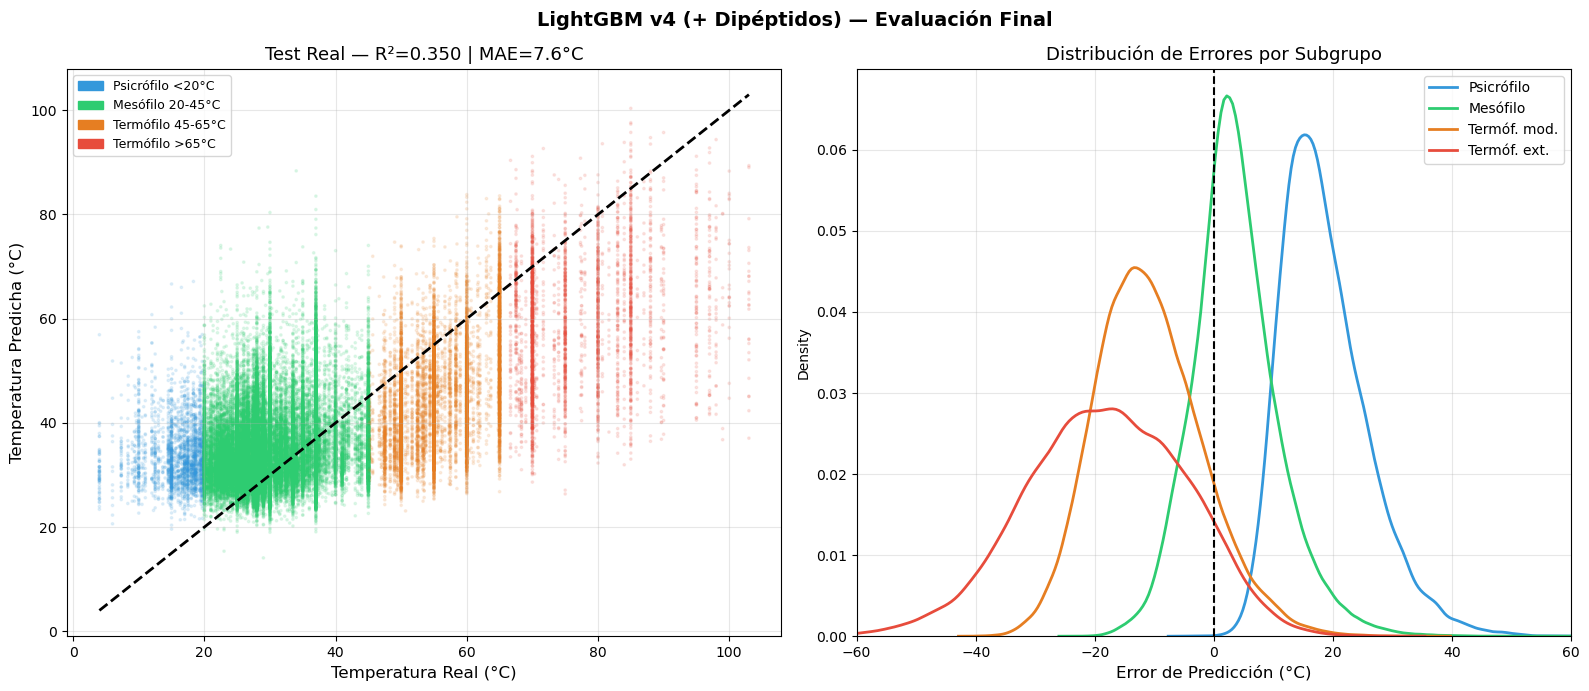


✅ Modelo guardado: /Users/fabian/Downloads/modelo_lgb_v4_dipeptidos.txt


In [ ]:
# Visualización final
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

idx_viz = np.random.choice(N_TEST, min(100_000, N_TEST), replace=False)
y_v, p_v = y_test[idx_viz], pred_test[idx_viz]
col_v = np.select([y_v<20, y_v<=45, y_v<=65],
                   ['#3498db','#2ecc71','#e67e22'], default='#e74c3c')

axes[0].scatter(y_v, p_v, c=col_v, alpha=0.12, s=3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_xlabel('Temperatura Real (°C)', fontsize=12)
axes[0].set_ylabel('Temperatura Predicha (°C)', fontsize=12)
axes[0].set_title(f'Test Real — R²={r2_t:.3f} | MAE={mae_t:.1f}°C', fontsize=13)
axes[0].grid(alpha=0.3)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3498db', label='Psicrófilo <20°C'),
    Patch(color='#2ecc71', label='Mesófilo 20-45°C'),
    Patch(color='#e67e22', label='Termófilo 45-65°C'),
    Patch(color='#e74c3c', label='Termófilo >65°C'),
], fontsize=9)

for color, label, mask in [
    ('#3498db', 'Psicrófilo',   y_test < 20),
    ('#2ecc71', 'Mesófilo',     (y_test>=20)&(y_test<=45)),
    ('#e67e22', 'Termóf. mod.', (y_test>45)&(y_test<=65)),
    ('#e74c3c', 'Termóf. ext.', y_test > 65),
]:
    if mask.sum() > 100:
        sns.kdeplot(pred_test[mask]-y_test[mask], ax=axes[1],
                    color=color, label=label, linewidth=2)

axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlim(-60, 60)
axes[1].set_xlabel('Error de Predicción (°C)', fontsize=12)
axes[1].set_title('Distribución de Errores por Subgrupo', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('LightGBM v4 (+ Dipéptidos) — Evaluación Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Guardar modelo
RUTA_MODELO = '/TU/RUTA/modelo_lgb_v4_dipeptidos.txt'
modelo.save_model(RUTA_MODELO)
print(f'\n✅ Modelo guardado: {RUTA_MODELO}')

## PASO 6: Clasificador de Screening (Psicrofilo / Mesofilo / Termofilo)

Un clasificador complementario al regresor. Útil para screening industrial:
en lugar de predecir una temperatura exacta, responde la pregunta
**¿esta enzima es termoestable?** — con mayor precisión en los extremos
gracias a `class_weight='balanced'` y los 428 features con dipéptidos.

**Variables del v4 que reutilizamos:**
| Variable original | Equivale a |
|---|---|
| `y_train_bal` | `y_tr` |
| `X_features` | `X_tr` |
| `extraer_features()` | `extraer_features_v4()` |
| `X_test_mmap` | se carga de nuevo con mmap |

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print('--- SCREENING VECTRA: Clasificador LightGBM + Dipéptidos ---')

# Función de categorización
def categorizar(temp):
    if temp < 20:    return '1. Psicrófilo (<20°C)'
    elif temp <= 45: return '2. Mesófilo (20-45°C)'
    else:            return '3. Termófilo (>45°C)'

# 1. Categorizar etiquetas de entrenamiento
# y_tr y X_tr son las variables de entrenamiento que ya existen en el v4
print('1. Categorizando datos de entrenamiento...')
y_tr_cat = np.vectorize(categorizar)(y_tr)
for cat in sorted(set(y_tr_cat)):
    print(f'   {cat}: {(y_tr_cat == cat).sum():,}')

# 2. Entrenar clasificador usando X_tr (ya tiene los 428 features)
print('\n2. Entrenando clasificador LightGBM...')
modelo_filtro = lgb.LGBMClassifier(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.05,
    class_weight='balanced',  # compensa desbalance entre categorías
    subsample=0.8,
    colsample_bytree=0.4,     # 40% de 428 features por árbol (igual que regresor)
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
modelo_filtro.fit(X_tr, y_tr_cat)
print('   Clasificador entrenado')

# 3. Evaluación rápida en validación (X_val ya existe)
pred_val_cat = modelo_filtro.predict(X_val)
y_val_cat    = np.vectorize(categorizar)(y_val)
print('\n3. Reporte en validación:')
print(classification_report(y_val_cat, pred_val_cat,
      target_names=['Psicrófilo', 'Mesófilo', 'Termófilo']))


--- SCREENING VECTRA: Clasificador LightGBM + Dipéptidos ---
1. Categorizando datos de entrenamiento...
   1. Psicrófilo (<20°C): 9,966
   2. Mesófilo (20-45°C): 333,970
   3. Termófilo (>45°C): 56,064

2. Entrenando clasificador LightGBM...
   Clasificador entrenado


/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



3. Reporte en validación:
              precision    recall  f1-score   support

  Psicrófilo       0.06      0.34      0.10      2492
    Mesófilo       0.93      0.66      0.77     83471
   Termófilo       0.38      0.73      0.50     14037

    accuracy                           0.66    100000
   macro avg       0.46      0.58      0.46    100000
weighted avg       0.83      0.66      0.72    100000



In [ ]:
# 4. Evaluación en el test set real por lotes
print('4. Clasificando Test Set real por lotes...')
X_test_mmap_cls = np.load(RUTA_X_TEST, mmap_mode='r')
y_test_cls      = np.load(RUTA_Y_TEST)
N_TEST_CLS      = len(y_test_cls)
print(f'   {N_TEST_CLS:,} proteínas')

y_test_cat_all  = []
pred_filtro_all = []

for i in range(0, N_TEST_CLS, LOTE):
    fin        = min(i + LOTE, N_TEST_CLS)
    X_lote     = np.array(X_test_mmap_cls[i:fin])
    feats_lote = extraer_features_v4(X_lote)   # misma función del v4
    y_lote_cat = np.vectorize(categorizar)(y_test_cls[i:fin])
    preds_lote = modelo_filtro.predict(feats_lote)

    y_test_cat_all.extend(y_lote_cat)
    pred_filtro_all.extend(preds_lote)

    del X_lote, feats_lote
    if (i // LOTE + 1) % 10 == 0 or fin == N_TEST_CLS:
        print(f'   {fin:,} / {N_TEST_CLS:,}')
        gc.collect()

print('\n' + '=' * 58)
print('REPORTE DEL CLASIFICADOR DE SCREENING (TEST REAL)')
print('=' * 58)
print(classification_report(y_test_cat_all, pred_filtro_all,
      target_names=['Psicrófilo', 'Mesófilo', 'Termófilo']))
print('=' * 58)


4. Clasificando Test Set real por lotes...
   1,537,340 proteínas


/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LG

   500,000 / 1,537,340


/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LG

   1,000,000 / 1,537,340


/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LG

   1,500,000 / 1,537,340


/opt/miniconda3/envs/protein_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   1,537,340 / 1,537,340

REPORTE DEL CLASIFICADOR DE SCREENING (TEST REAL)
              precision    recall  f1-score   support

  Psicrófilo       0.06      0.35      0.11     38546
    Mesófilo       0.93      0.66      0.77   1282663
   Termófilo       0.37      0.73      0.49    216131

    accuracy                           0.66   1537340
   macro avg       0.46      0.58      0.46   1537340
weighted avg       0.83      0.66      0.71   1537340



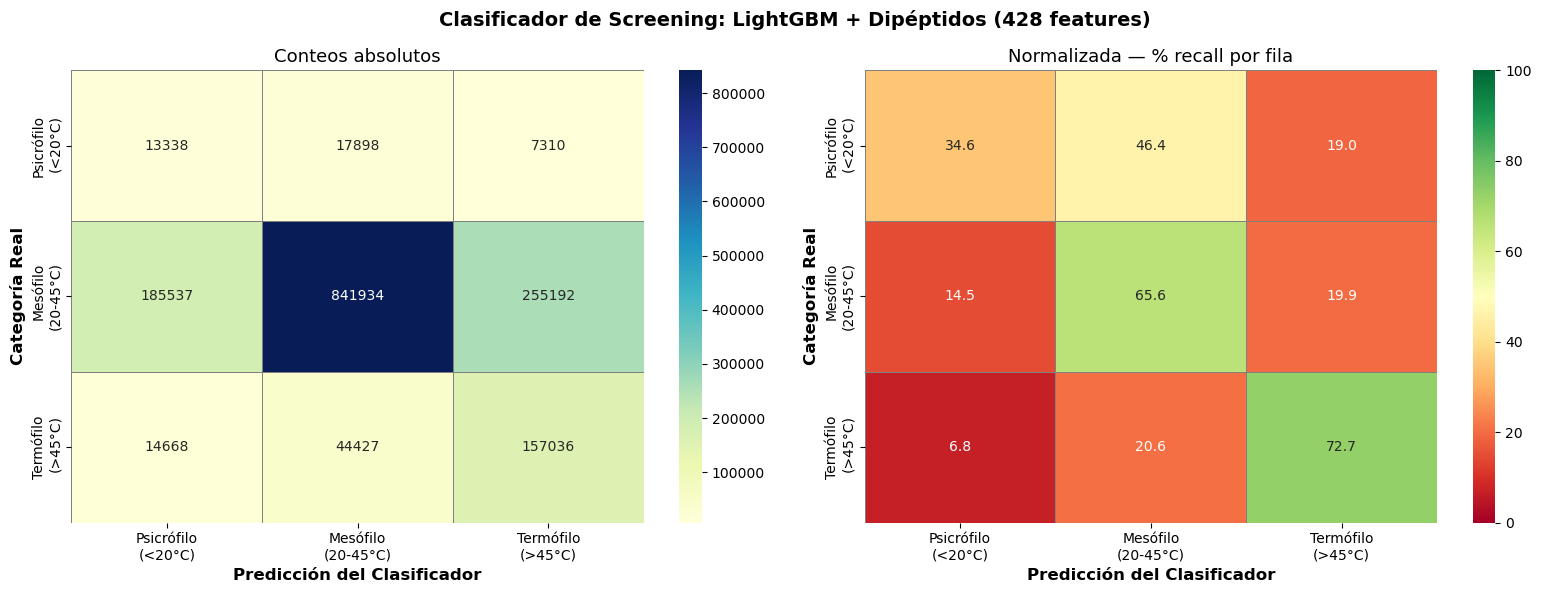

Clasificador guardado: /Users/fabian/Downloads/clasificador_screening_v4.txt
Para cargar: lgb.Booster(model_file=RUTA_CLAS)


In [ ]:
# 5. Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
etiquetas = ['Psicrófilo\n(<20°C)', 'Mesófilo\n(20-45°C)', 'Termófilo\n(>45°C)']
matriz = confusion_matrix(y_test_cat_all, pred_filtro_all)

# Absoluta
sns.heatmap(matriz, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0],
            xticklabels=etiquetas, yticklabels=etiquetas,
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicción del Clasificador', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Categoría Real', fontsize=12, fontweight='bold')
axes[0].set_title('Conteos absolutos', fontsize=13)

# Normalizada por fila (recall por categoría)
matriz_norm = matriz.astype(float) / matriz.sum(axis=1, keepdims=True) * 100
sns.heatmap(matriz_norm, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=etiquetas, yticklabels=etiquetas,
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicción del Clasificador', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Categoría Real', fontsize=12, fontweight='bold')
axes[1].set_title('Normalizada — % recall por fila', fontsize=13)

plt.suptitle('Clasificador de Screening: LightGBM + Dipéptidos (428 features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Guardar clasificador
RUTA_CLAS = '/TU/RUTA/clasificador_screening_v4.txt'
modelo_filtro.booster_.save_model(RUTA_CLAS)
print(f'Clasificador guardado: {RUTA_CLAS}')
print('Para cargar: lgb.Booster(model_file=RUTA_CLAS)')
